# Quiz 1 — Part 2: Balanced + Proper Split (From-Scratch Base Models)
## Topic E: Transfer Learning for Medical Imaging
### Dataset: Chest X-Ray Pneumonia — https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

**Goal of this notebook:** fix the two flaws from Part 1 and train a clean set of
**from-scratch** baselines we can later compare against fine-tuned models (Part 3).

Fixes applied:
1. **Proper split** — merge the original `train/val/test`, then **stratified** 80/10/10
   re-split so every split has the same class ratio and the val set is large enough.
2. **Class balancing** — a `WeightedRandomSampler` makes each mini-batch ~50/50.

| # | Model | Mode | Balancing |
|---|---|---|---|
| 1 | SimpleCNN   | From Scratch | WeightedRandomSampler |
| 2 | VGG16       | From Scratch | WeightedRandomSampler |
| 3 | ResNet50    | From Scratch | WeightedRandomSampler |
| 4 | MobileNetV2 | From Scratch | WeightedRandomSampler |

All four use **random init (no ImageNet weights)** — these are the *scratch* baselines.

## 1. Setup & Imports

In [1]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device   : {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device   : cuda
PyTorch version: 2.10.0+cu128


## 2. Merge All Data & Stratified Re-Split (80 / 10 / 10)

The original split is imbalanced with a 16-image val set. We merge everything and
re-split with stratification so each split preserves the class ratio.

In [2]:
import shutil
DATA_DIR   = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'  # adjust if your path differs
MERGED_DIR = '/kaggle/working/merged'
CLASSES    = ['NORMAL', 'PNEUMONIA']

os.makedirs(MERGED_DIR, exist_ok=True)
for cls in CLASSES:
    os.makedirs(os.path.join(MERGED_DIR, cls), exist_ok=True)

total = 0
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        src = os.path.join(DATA_DIR, split, cls)
        if not os.path.exists(src):
            continue
        for fname in os.listdir(src):
            dst = os.path.join(MERGED_DIR, cls, f'{split}_{fname}')
            if not os.path.exists(dst):
                shutil.copy2(os.path.join(src, fname), dst); total += 1
print(f'Merged {total} images')
for cls in CLASSES:
    print(f'  {cls}: {len(os.listdir(os.path.join(MERGED_DIR, cls)))}')

Merged 5856 images
  NORMAL: 1583
  PNEUMONIA: 4273


In [3]:
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

base_dataset = datasets.ImageFolder(MERGED_DIR)
all_targets  = [y for _, y in base_dataset.samples]
CLASS_NAMES  = base_dataset.classes
print(f'Total {len(base_dataset)} | classes {CLASS_NAMES} | dist {dict(Counter(all_targets))}')

# Stratified 80 / 10 / 10
train_idx, temp_idx = train_test_split(range(len(base_dataset)), test_size=0.2,
                                       stratify=all_targets, random_state=42)
temp_t = [all_targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_t, random_state=42)

for nm, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    print(f'{nm:5s}: {len(idx):5d} ({len(idx)/len(base_dataset)*100:4.1f}%)  dist={dict(Counter([all_targets[i] for i in idx]))}')

Total 5856 | classes ['NORMAL', 'PNEUMONIA'] | dist {0: 1583, 1: 4273}
Train:  4684 (80.0%)  dist={1: 3418, 0: 1266}
Val  :   586 (10.0%)  dist={0: 159, 1: 427}
Test :   586 (10.0%)  dist={0: 158, 1: 428}


## 3. Transforms, Balanced Sampler & Loaders

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class TransformSubset(torch.utils.data.Dataset):
    """Apply a transform to a subset of indices of an ImageFolder."""
    def __init__(self, dataset, indices, transform):
        self.dataset, self.indices, self.transform = dataset, indices, transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.dataset.samples[self.indices[i]]
        return self.transform(Image.open(path).convert('RGB')), label

train_dataset = TransformSubset(base_dataset, train_idx, train_transforms)
val_dataset   = TransformSubset(base_dataset, val_idx,   eval_transforms)
test_dataset  = TransformSubset(base_dataset, test_idx,  eval_transforms)

# --- BALANCING: WeightedRandomSampler -> each mini-batch is ~50/50 ---
train_labels = [all_targets[i] for i in train_idx]
class_count  = Counter(train_labels)
class_w      = {c: 1.0/n for c, n in class_count.items()}
sample_w     = [class_w[t] for t in train_labels]
sampler      = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
print('Loaders ready. Sampler rebalances the', f'{class_count[1]/class_count[0]:.2f}:1', 'train imbalance to ~1:1 per batch.')

Loaders ready. Sampler rebalances the 2.70:1 train imbalance to ~1:1 per batch.


## 4. Dataset Exploration & Visualization

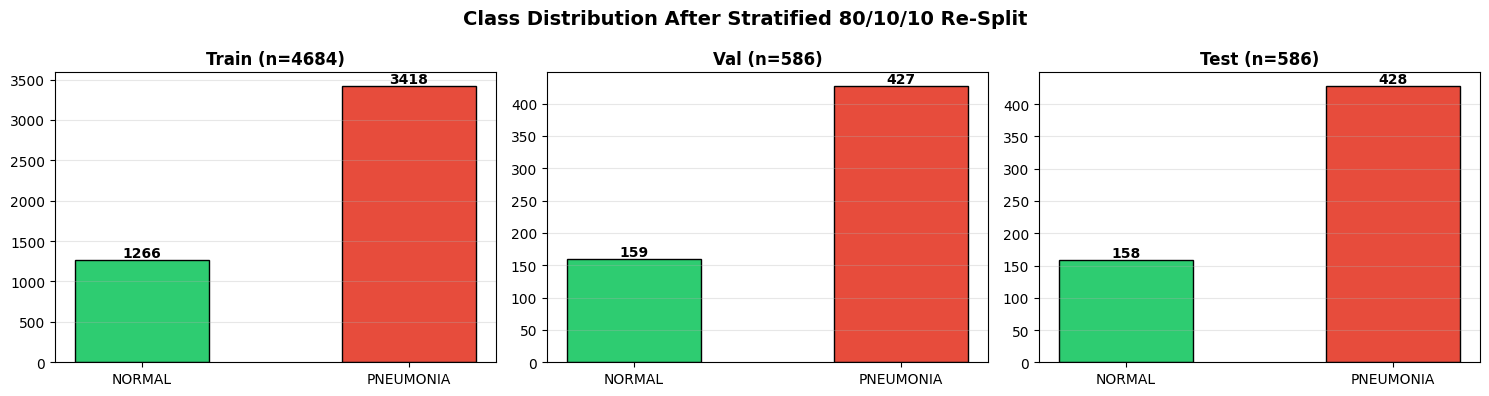

In [5]:
# Class distribution after stratified split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#2ecc71', '#e74c3c']
for ax, (nm, idx) in zip(axes, [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]):
    cnt  = Counter([all_targets[i] for i in idx])
    vals = [cnt[i] for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, vals, color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{nm} (n={sum(vals)})', fontweight='bold'); ax.grid(axis='y', alpha=.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), str(v), ha='center', va='bottom', fontweight='bold')
plt.suptitle('Class Distribution After Stratified 80/10/10 Re-Split', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('p2_class_distribution.png', bbox_inches='tight', dpi=150); plt.show()

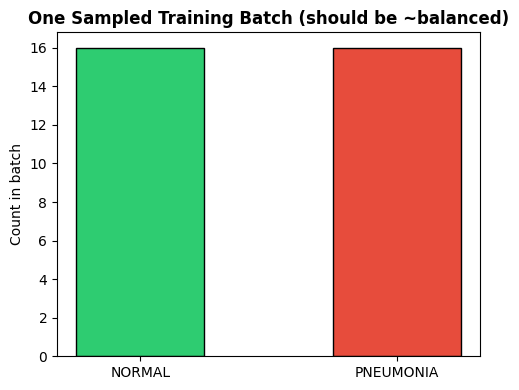

Batch class counts: {1: 16, 0: 16}


In [6]:
# Verify the sampler really balances a batch
imgs, lbls = next(iter(train_loader))
bc = Counter(lbls.numpy().tolist())
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([CLASS_NAMES[k] for k in sorted(bc)], [bc[k] for k in sorted(bc)],
       color=colors, edgecolor='black', width=0.5)
ax.set_title('One Sampled Training Batch (should be ~balanced)', fontweight='bold'); ax.set_ylabel('Count in batch')
plt.tight_layout(); plt.savefig('p2_sampled_batch.png', bbox_inches='tight', dpi=150); plt.show()
print('Batch class counts:', dict(bc))

## 5. Models — From-Scratch Base (CNN, VGG16, ResNet50, MobileNetV2)

In [7]:
# A small CNN built FROM SCRATCH (our own architecture, no ImageNet weights).
# 4 conv blocks -> global average pool -> dropout -> linear. ~0.4M params.
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3,   32),   # 224 -> 112
            block(32,  64),   # 112 -> 56
            block(64,  128),  # 56  -> 28
            block(128, 128),  # 28  -> 14
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [8]:
def build_model(arch, num_classes=2):
    """All FROM SCRATCH (weights=None) — these are the scratch baselines."""
    if arch == 'cnn':
        return SimpleCNN(num_classes)
    if arch == 'vgg16':
        m = models.vgg16(weights=None)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
        return m
    if arch == 'resnet50':
        m = models.resnet50(weights=None)
        m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, num_classes))
        return m
    if arch == 'mobilenetv2':
        m = models.mobilenet_v2(weights=None)
        m.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.classifier[1].in_features, num_classes))
        return m
    raise ValueError(arch)

## 6. Training & Evaluation Functions

In [9]:
def train_model(model, train_loader, val_loader, num_epochs=20,
                lr=1e-3, patience=6, experiment_name='model',
                class_weights=None):
    """Train + validate. Returns (best_model, history).
    class_weights: optional tensor passed to CrossEntropyLoss (weighted loss).
    Best checkpoint = highest (val_acc + val_auc), ties broken by lower val_loss."""
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
    best_score, best_val_loss = 0.0, float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    no_improve = 0

    print(f'\n{"="*60}\n  {experiment_name}\n{"="*60}')
    for epoch in range(num_epochs):
        start = time.time()
        # ---- train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        bar = tqdm(train_loader, desc=f'Epoch [{epoch+1:02d}/{num_epochs}] Train', leave=False)
        for inputs, labels in bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item(); total += labels.size(0)
            bar.set_postfix(loss=f'{running_loss/total:.4f}', acc=f'{correct/total:.4f}')
        train_loss, train_acc = running_loss/total, correct/total

        # ---- val ----
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        vp, vl = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item(); total += labels.size(0)
                vp.extend(torch.softmax(outputs, 1)[:, 1].cpu().numpy())
                vl.extend(labels.cpu().numpy())
        val_loss, val_acc = running_loss/total, correct/total
        val_auc = roc_auc_score(vl, vp) if len(set(vl)) > 1 else 0.5
        scheduler.step(val_loss)

        for k, v in zip(history, [train_loss, val_loss, train_acc, val_acc, val_auc]):
            history[k].append(v)
        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train L {train_loss:.4f} A {train_acc:.4f} | '
              f'Val L {val_loss:.4f} A {val_acc:.4f} AUC {val_auc:.4f} | {time.time()-start:.1f}s')

        score = val_acc + val_auc
        if score > best_score or (score == best_score and val_loss < best_val_loss):
            best_score, best_val_loss = score, val_loss
            best_weights = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1}'); break

    model.load_state_dict(best_weights)
    return model, history

In [10]:
def evaluate_model(model, loader):
    """Return accuracy, AUC-ROC, sklearn report dict, confusion matrix, raw preds."""
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for inputs, lbls in loader:
            p = torch.softmax(model(inputs.to(DEVICE)), 1)
            preds.extend(p.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
            probs.extend(p[:, 1].cpu().numpy())
    acc     = np.mean(np.array(preds) == np.array(labels))
    auc_roc = roc_auc_score(labels, probs) if len(set(labels)) > 1 else 0.5
    report  = classification_report(labels, preds, target_names=CLASS_NAMES, output_dict=True)
    return {'accuracy': acc, 'auc_roc': auc_roc, 'report': report,
            'confusion_matrix': confusion_matrix(labels, preds),
            'labels': labels, 'probs': probs, 'preds': preds}

In [11]:
def count_params(model, name=''):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name} | Total: {total:,} | Trainable: {train:,}')


def plot_training_curves(history, name):
    ep = range(1, len(history['train_loss']) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
    ax[0].plot(ep, history['train_loss'], 'b-o', label='Train', ms=4)
    ax[0].plot(ep, history['val_loss'],   'r-o', label='Val',   ms=4)
    ax[0].set_title(f'{name} - Loss', fontweight='bold'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(ep, history['train_acc'], 'b-o', label='Train', ms=4)
    ax[1].plot(ep, history['val_acc'],   'r-o', label='Val',   ms=4)
    ax[1].set_title(f'{name} - Accuracy', fontweight='bold'); ax[1].set_xlabel('Epoch'); ax[1].set_ylim([0,1]); ax[1].legend(); ax[1].grid(alpha=.3)
    ax[2].plot(ep, history['val_auc'], 'g-o', ms=4)
    ax[2].set_title(f'{name} - Val AUC', fontweight='bold'); ax[2].set_xlabel('Epoch'); ax[2].set_ylim([0,1]); ax[2].grid(alpha=.3)
    plt.tight_layout()
    plt.savefig(name.lower().replace(' ','_') + '_curves.png', bbox_inches='tight', dpi=150)
    plt.show()


def plot_confusion_matrix(cm, name):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, linewidths=1, linecolor='white', ax=ax)
    ax.set_title(f'Confusion Matrix - {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(name.lower().replace(' ','_') + '_cm.png', bbox_inches='tight', dpi=150)
    plt.show()

## 7. Run All Experiments

Four from-scratch models, identical recipe, balanced sampler. VGG16/ResNet50 are
heavy — drop `num_epochs` or skip one if compute is tight.

In [12]:
all_results, all_histories = {}, {}
EXPERIMENTS = [
    ('SimpleCNN Scratch',   'cnn'),
    ('VGG16 Scratch',       'vgg16'),
    ('ResNet50 Scratch',    'resnet50'),
    ('MobileNetV2 Scratch', 'mobilenetv2'),
]


Building SimpleCNN Scratch...
SimpleCNN Scratch | Total: 241,794 | Trainable: 241,794

  SimpleCNN Scratch


Epoch [01/25]  Train L 0.4491 A 0.8079 | Val L 0.2658 A 0.8823 AUC 0.9479 | 54.9s


Epoch [02/25]  Train L 0.3271 A 0.8740 | Val L 0.2491 A 0.9181 AUC 0.9704 | 53.8s


Epoch [03/25]  Train L 0.3063 A 0.8775 | Val L 1.4468 A 0.5631 AUC 0.9363 | 53.7s


Epoch [04/25]  Train L 0.2872 A 0.8858 | Val L 0.2563 A 0.8754 AUC 0.9796 | 53.0s


...

Epoch [21/25]  Train L 0.1657 A 0.9368 | Val L 0.1182 A 0.9573 AUC 0.9889 | 53.6s


Epoch [22/25]  Train L 0.1711 A 0.9349 | Val L 0.1959 A 0.9352 AUC 0.9905 | 54.2s


Epoch [23/25]  Train L 0.1686 A 0.9381 | Val L 0.1923 A 0.9249 AUC 0.9913 | 54.1s


Epoch [24/25]  Train L 0.1494 A 0.9468 | Val L 0.1601 A 0.9369 AUC 0.9914 | 54.4s


Epoch [25/25]  Train L 0.1585 A 0.9430 | Val L 0.1414 A 0.9403 AUC 0.9910 | 53.6s
Early stopping at epoch 25


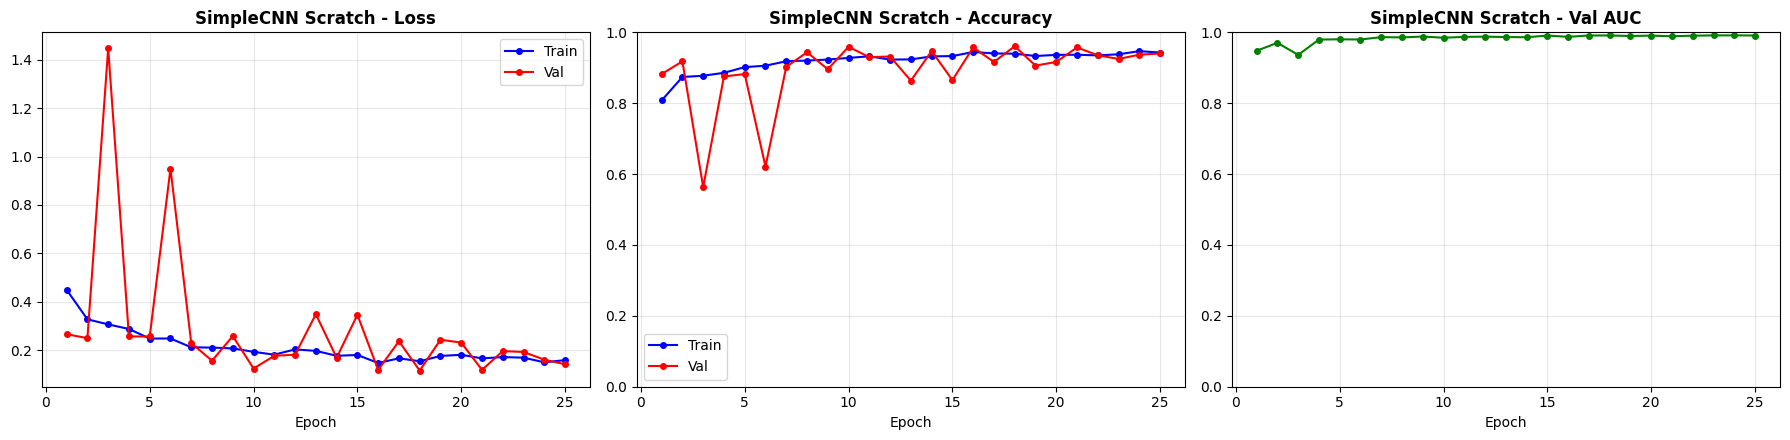

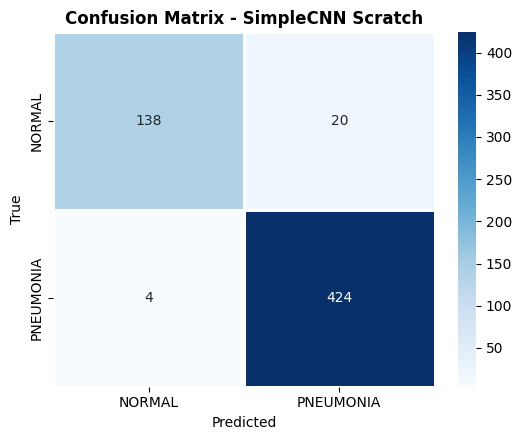

Accuracy 0.9590 | AUC-ROC 0.9825
              precision    recall  f1-score   support

      NORMAL       0.97      0.87      0.92       158
   PNEUMONIA       0.95      0.99      0.97       428

    accuracy                           0.96       586
   macro avg       0.96      0.93      0.95       586
weighted avg       0.96      0.96      0.96       586



In [13]:
# Experiment 1
name, arch = EXPERIMENTS[0]
print(f'\nBuilding {name}...')
model = build_model(arch); count_params(model, name)
model, hist = train_model(model, train_loader, val_loader,
                          num_epochs=25, lr=1e-3, patience=7, experiment_name=name)
plot_training_curves(hist, name)
res = evaluate_model(model, test_loader)
plot_confusion_matrix(res['confusion_matrix'], name)
print(f"Accuracy {res['accuracy']:.4f} | AUC-ROC {res['auc_roc']:.4f}")
print(classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES))
all_results[name], all_histories[name] = res, hist
del model


Building VGG16 Scratch...
VGG16 Scratch | Total: 134,268,738 | Trainable: 134,268,738

  VGG16 Scratch


Epoch [01/25]  Train L 1.1597 A 0.4977 | Val L 0.6891 A 0.7287 AUC 0.6483 | 76.9s


Epoch [02/25]  Train L 0.6933 A 0.4972 | Val L 0.7034 A 0.2713 AUC 0.5000 | 76.4s


Epoch [03/25]  Train L 0.6933 A 0.5019 | Val L 0.7018 A 0.2713 AUC 0.5000 | 75.6s


Epoch [04/25]  Train L 0.6932 A 0.5068 | Val L 0.7016 A 0.2713 AUC 0.4969 | 75.7s


Epoch [05/25]  Train L 0.6934 A 0.4955 | Val L 0.6963 A 0.2713 AUC 0.5000 | 75.9s


Epoch [06/25]  Train L 0.6932 A 0.5053 | Val L 0.6967 A 0.2713 AUC 0.5000 | 75.4s


Epoch [07/25]  Train L 0.6933 A 0.5006 | Val L 0.6926 A 0.7287 AUC 0.5000 | 76.3s


Epoch [08/25]  Train L 0.6932 A 0.5015 | Val L 0.6884 A 0.7287 AUC 0.5000 | 75.5s
Early stopping at epoch 8


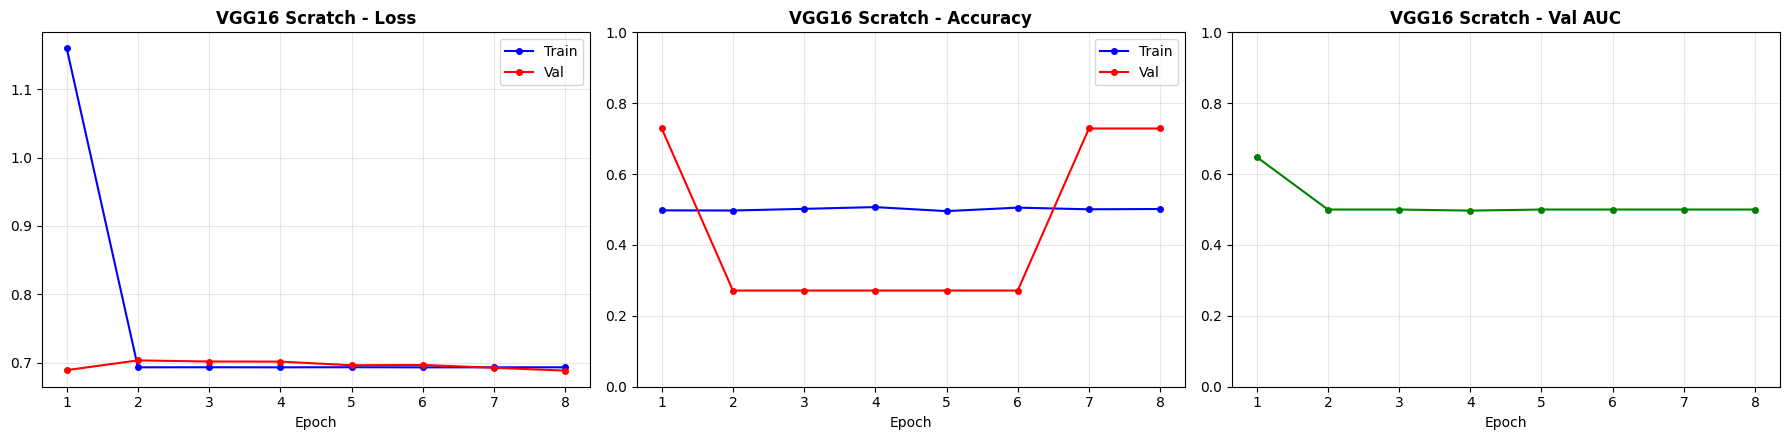

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


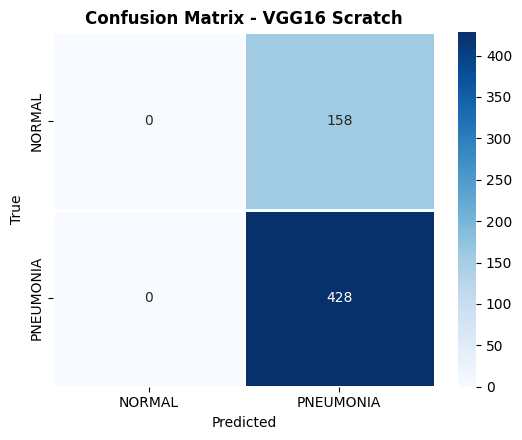

Accuracy 0.7304 | AUC-ROC 0.6268
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       158
   PNEUMONIA       0.73      1.00      0.84       428

    accuracy                           0.73       586
   macro avg       0.37      0.50      0.42       586
weighted avg       0.53      0.73      0.62       586



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
# Experiment 2
name, arch = EXPERIMENTS[1]
print(f'\nBuilding {name}...')
model = build_model(arch); count_params(model, name)
model, hist = train_model(model, train_loader, val_loader,
                          num_epochs=25, lr=1e-3, patience=7, experiment_name=name)
plot_training_curves(hist, name)
res = evaluate_model(model, test_loader)
plot_confusion_matrix(res['confusion_matrix'], name)
print(f"Accuracy {res['accuracy']:.4f} | AUC-ROC {res['auc_roc']:.4f}")
print(classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES))
all_results[name], all_histories[name] = res, hist
del model


Building ResNet50 Scratch...
ResNet50 Scratch | Total: 23,512,130 | Trainable: 23,512,130

  ResNet50 Scratch


Epoch [01/25]  Train L 0.4578 A 0.8179 | Val L 0.3828 A 0.8123 AUC 0.9500 | 64.5s


Epoch [02/25]  Train L 0.2746 A 0.8890 | Val L 1.5168 A 0.6160 AUC 0.9752 | 66.0s


Epoch [03/25]  Train L 0.2631 A 0.8947 | Val L 0.3331 A 0.8498 AUC 0.9831 | 66.1s


Epoch [04/25]  Train L 0.2331 A 0.9127 | Val L 0.1353 A 0.9522 AUC 0.9858 | 66.3s


...

Epoch [21/25]  Train L 0.0996 A 0.9643 | Val L 0.1250 A 0.9642 AUC 0.9941 | 66.1s


Epoch [22/25]  Train L 0.0891 A 0.9665 | Val L 0.0805 A 0.9744 AUC 0.9940 | 67.4s


Epoch [23/25]  Train L 0.0813 A 0.9708 | Val L 0.1145 A 0.9642 AUC 0.9956 | 67.4s


Epoch [24/25]  Train L 0.0889 A 0.9667 | Val L 0.0737 A 0.9727 AUC 0.9958 | 68.4s


Epoch [25/25]  Train L 0.0787 A 0.9708 | Val L 0.0957 A 0.9608 AUC 0.9956 | 68.9s


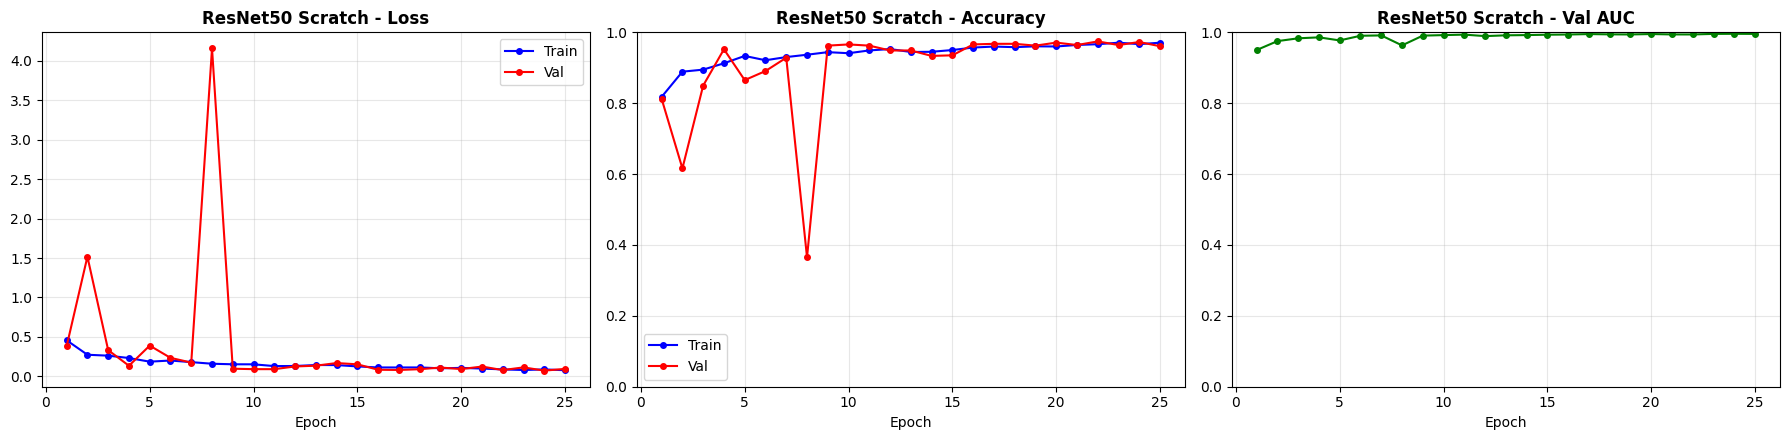

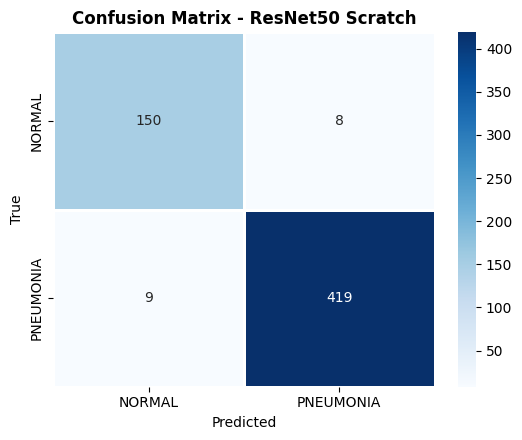

Accuracy 0.9710 | AUC-ROC 0.9963
              precision    recall  f1-score   support

      NORMAL       0.94      0.95      0.95       158
   PNEUMONIA       0.98      0.98      0.98       428

    accuracy                           0.97       586
   macro avg       0.96      0.96      0.96       586
weighted avg       0.97      0.97      0.97       586



In [15]:
# Experiment 3
name, arch = EXPERIMENTS[2]
print(f'\nBuilding {name}...')
model = build_model(arch); count_params(model, name)
model, hist = train_model(model, train_loader, val_loader,
                          num_epochs=25, lr=1e-3, patience=7, experiment_name=name)
plot_training_curves(hist, name)
res = evaluate_model(model, test_loader)
plot_confusion_matrix(res['confusion_matrix'], name)
print(f"Accuracy {res['accuracy']:.4f} | AUC-ROC {res['auc_roc']:.4f}")
print(classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES))
all_results[name], all_histories[name] = res, hist
del model


Building MobileNetV2 Scratch...
MobileNetV2 Scratch | Total: 2,226,434 | Trainable: 2,226,434

  MobileNetV2 Scratch


Epoch [01/25]  Train L 0.4046 A 0.8320 | Val L 0.3354 A 0.8959 AUC 0.9631 | 61.3s


Epoch [02/25]  Train L 0.2925 A 0.8815 | Val L 1.3901 A 0.7065 AUC 0.9588 | 61.3s


Epoch [03/25]  Train L 0.2415 A 0.9033 | Val L 0.1869 A 0.9334 AUC 0.9738 | 60.9s


Epoch [04/25]  Train L 0.2058 A 0.9172 | Val L 0.2850 A 0.8891 AUC 0.9788 | 60.7s


...

Epoch [21/25]  Train L 0.0844 A 0.9682 | Val L 0.1254 A 0.9488 AUC 0.9935 | 57.6s


Epoch [22/25]  Train L 0.0958 A 0.9637 | Val L 0.1357 A 0.9505 AUC 0.9921 | 56.2s


Epoch [23/25]  Train L 0.1000 A 0.9592 | Val L 0.1435 A 0.9573 AUC 0.9933 | 57.8s


Epoch [24/25]  Train L 0.0826 A 0.9705 | Val L 0.0956 A 0.9625 AUC 0.9949 | 56.9s


Epoch [25/25]  Train L 0.0825 A 0.9693 | Val L 0.0788 A 0.9727 AUC 0.9951 | 56.8s


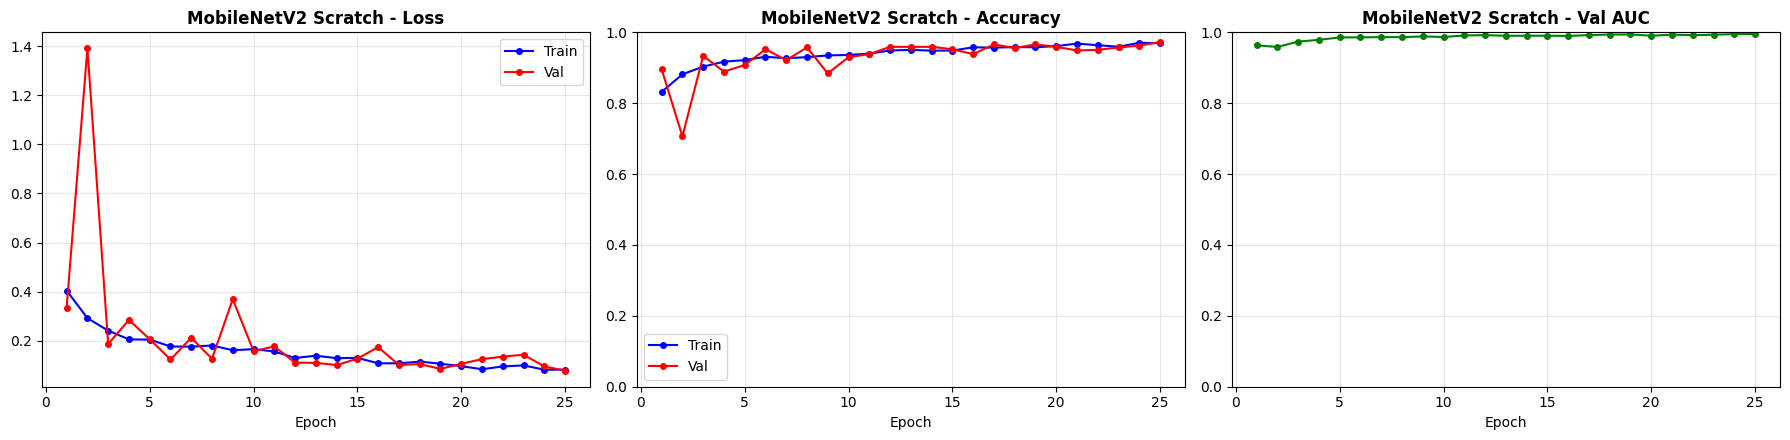

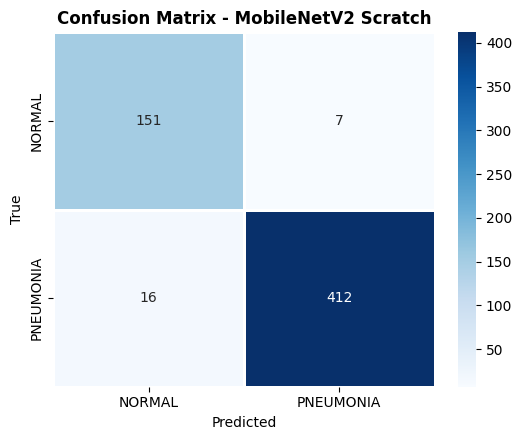

Accuracy 0.9608 | AUC-ROC 0.9955
              precision    recall  f1-score   support

      NORMAL       0.90      0.96      0.93       158
   PNEUMONIA       0.98      0.96      0.97       428

    accuracy                           0.96       586
   macro avg       0.94      0.96      0.95       586
weighted avg       0.96      0.96      0.96       586



In [16]:
# Experiment 4
name, arch = EXPERIMENTS[3]
print(f'\nBuilding {name}...')
model = build_model(arch); count_params(model, name)
model, hist = train_model(model, train_loader, val_loader,
                          num_epochs=25, lr=1e-3, patience=7, experiment_name=name)
plot_training_curves(hist, name)
res = evaluate_model(model, test_loader)
plot_confusion_matrix(res['confusion_matrix'], name)
print(f"Accuracy {res['accuracy']:.4f} | AUC-ROC {res['auc_roc']:.4f}")
print(classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES))
all_results[name], all_histories[name] = res, hist
del model

## 8. Results Comparison & Visualizations

In [17]:
rows = []
for n, r in all_results.items():
    rep = r['report']
    rows.append({'Model': n, 'Accuracy': f"{r['accuracy']:.4f}", 'AUC-ROC': f"{r['auc_roc']:.4f}",
                 'Precision': f"{rep['weighted avg']['precision']:.4f}",
                 'Recall': f"{rep['weighted avg']['recall']:.4f}",
                 'Macro-F1': f"{rep['macro avg']['f1-score']:.4f}",
                 'NORMAL recall': f"{rep['NORMAL']['recall']:.4f}"})
summary_df = pd.DataFrame(rows)
print('='*100); print(summary_df.to_string(index=False)); print('='*100)
best = summary_df.loc[summary_df['Accuracy'].astype(float).idxmax(), 'Model']
print('Best scratch model by accuracy:', best)

              Model Accuracy AUC-ROC Precision Recall Macro-F1 NORMAL recall
  SimpleCNN Scratch   0.9590  0.9825    0.9595 0.9590   0.9462        0.8734
      VGG16 Scratch   0.7304  0.6268    0.5334 0.7304   0.4221        0.0000
   ResNet50 Scratch   0.9710  0.9963    0.9711 0.9710   0.9632        0.9494
MobileNetV2 Scratch   0.9608  0.9955    0.9620 0.9608   0.9510        0.9557
Best scratch model by accuracy: ResNet50 Scratch


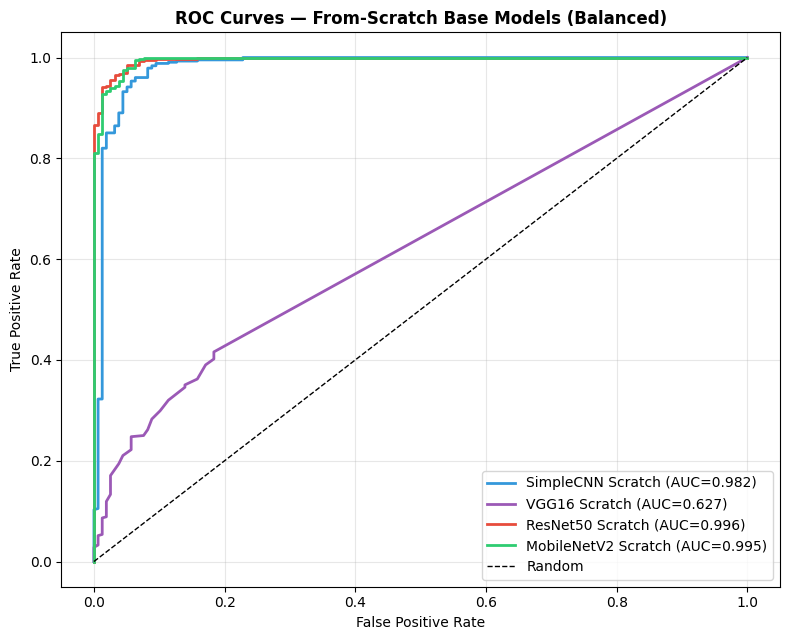

In [18]:
# ROC curves — all four
fig, ax = plt.subplots(figsize=(8, 6.5))
for (n, r), c in zip(all_results.items(), ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71']):
    fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
    ax.plot(fpr, tpr, lw=2, color=c, label=f"{n} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — From-Scratch Base Models (Balanced)', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('p2_roc_curves.png', bbox_inches='tight', dpi=150); plt.show()

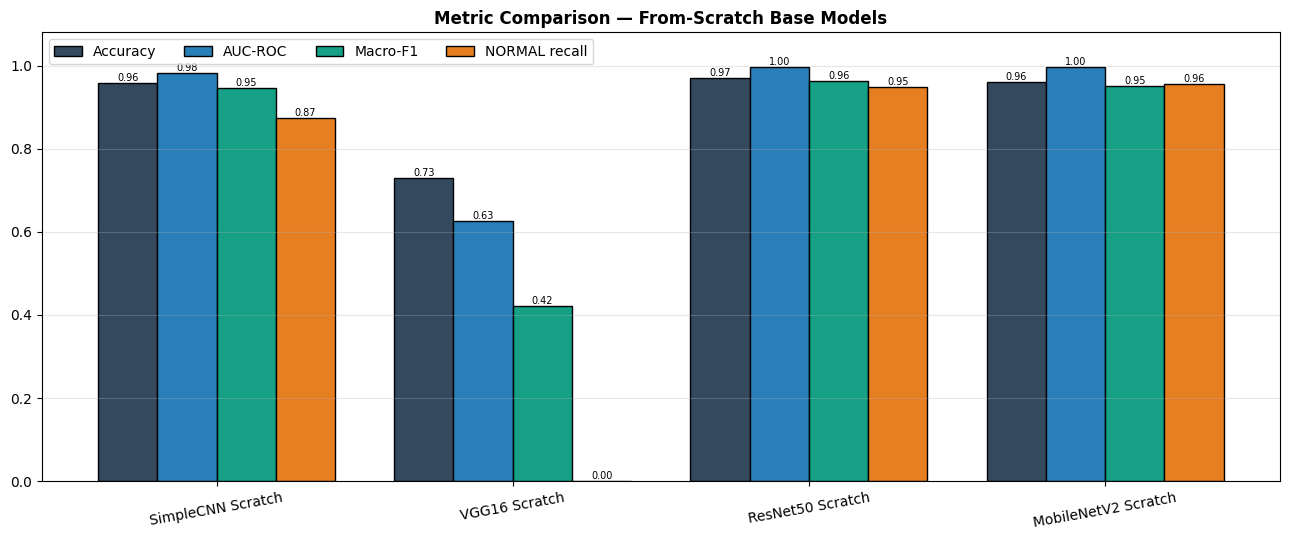

In [19]:
# Grouped bar — metrics across models
metrics = ['Accuracy', 'AUC-ROC', 'Macro-F1', 'NORMAL recall']
mods = list(all_results.keys())
x = np.arange(len(mods)); w = 0.2
fig, ax = plt.subplots(figsize=(13, 5.5))
palette = ['#34495e', '#2980b9', '#16a085', '#e67e22']
for j, m in enumerate(metrics):
    vals = summary_df[m].astype(float).values
    bars = ax.bar(x + (j - 1.5)*w, vals, w, label=m, color=palette[j], edgecolor='black')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.2f}',
                ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(mods, rotation=10); ax.set_ylim([0, 1.08])
ax.set_title('Metric Comparison — From-Scratch Base Models', fontweight='bold')
ax.legend(ncol=4); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.savefig('p2_metric_comparison.png', bbox_inches='tight', dpi=150); plt.show()

## 9. Discussion & Next Step

- With a **proper stratified split** the val set is now large enough for reliable
  early-stopping, and **NORMAL (minority) recall** rises versus Part 1 thanks to the
  **balanced sampler** — accuracy and recall now move together.
- These are **from-scratch** numbers. Deep nets (VGG16, ResNet50) trained from random
  init on a few thousand X-rays tend to underperform or overfit relative to the small
  SimpleCNN — that gap is exactly what **transfer learning** closes.

➡️ **Part 3** fine-tunes ImageNet-pretrained VGG16 / ResNet50 / MobileNetV2 on this
same balanced split and compares **scratch vs fine-tuned**, adds **Grad-CAM**.